In [1]:
print("hi")

hi


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [15]:
import pandas as pd

df = pd.read_excel(r'/Users/mac/Downloads/simulated_churn_data.xlsx')
print(df.head(2))

   customerid  gender  seniorcitizen partner dependents  tenure phoneservice  \
0  CUST100000    Male            1.0     Yes         No     1.0          Yes   
1  CUST100001  Female            1.0     Yes         No     0.0          Yes   

  multiplelines internetservices onlinesecurity  ... deviceprotection  \
0            No      Fiber optic            Yes  ...               No   
1            No              NaN            Yes  ...              Yes   

  techsupport streamingtv streamingmovies        contract paperlessbilling  \
0         Yes          No              No  Month-to-month              Yes   
1         Yes          No             Yes  Month-to-month              Yes   

      paymentmethod monthlycharges  totalcharges  churn  
0  Electronic check          44.51       5406.45     No  
1      Mailed check          62.61       3528.94     No  

[2 rows x 21 columns]


In [16]:
df.isnull().sum()

customerid            0
gender              149
seniorcitizen       291
partner             447
dependents          393
tenure               76
phoneservice        168
multiplelines       156
internetservices    156
onlinesecurity      147
onlinebackup        148
deviceprotection    153
techsupport         154
streamingtv         146
streamingmovies     152
contract            153
paperlessbilling    143
paymentmethod       171
monthlycharges        0
totalcharges          0
churn               266
dtype: int64

In [17]:
df.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservices',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='object')

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        8000 non-null   object 
 1   gender            7851 non-null   object 
 2   seniorcitizen     7709 non-null   float64
 3   partner           7553 non-null   object 
 4   dependents        7607 non-null   object 
 5   tenure            7924 non-null   float64
 6   phoneservice      7832 non-null   object 
 7   multiplelines     7844 non-null   object 
 8   internetservices  7844 non-null   object 
 9   onlinesecurity    7853 non-null   object 
 10  onlinebackup      7852 non-null   object 
 11  deviceprotection  7847 non-null   object 
 12  techsupport       7846 non-null   object 
 13  streamingtv       7854 non-null   object 
 14  streamingmovies   7848 non-null   object 
 15  contract          7847 non-null   object 
 16  paperlessbilling  7857 non-null   object 


In [20]:
# replacing the all blank values with nan

In [21]:
df = df.replace(" ", np.nan)
df = df.replace("", np.nan)

In [22]:
# Convert to numeric where needed

In [23]:
df['totalcharges'] = pd.to_numeric(df['totalcharges'], errors='coerce')

In [24]:
cat_cols = [
    'gender', 'seniorcitizen', 'partner', 'dependents',
    'phoneservice', 'multiplelines', 'internetservices',
    'onlinesecurity', 'onlinebackup', 'deviceprotection',
    'techsupport', 'streamingtv', 'streamingmovies',
    'contract', 'paperlessbilling', 'paymentmethod',
    'churn'
]

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [25]:
# Fill numeric columns with median

In [26]:
num_cols = ['tenure', 'monthlycharges', 'totalcharges']
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

In [27]:
# Fill categorical columns with mode

In [28]:
cat_cols = [col for col in df.columns if col not in num_cols + ['customerid']]
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [29]:
# Check again

In [30]:
print(df.isnull().sum())

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservices    0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64


In [31]:
# check duplicate values in Customer ID

In [34]:
df['customerid'].duplicated().sum()

np.int64(0)

In [35]:
# now create a function to convert the values in senior citizen yes or no

In [36]:
def conv(value):
    if value == 1:
        return "yes"
    else:
        return "no"
df['seniorcitizen']=df['seniorcitizen'].apply(conv)

In [90]:
df.head(5)

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservices,onlinesecurity,...,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn,tenure_group
0,CUST100000,Male,yes,Yes,No,1.0,Yes,No,Fiber optic,Yes,...,Yes,No,No,Month-to-month,Yes,Electronic check,44.51,5406.45,No,Month-to-month
1,CUST100001,Female,yes,Yes,No,0.0,Yes,No,Fiber optic,Yes,...,Yes,No,Yes,Month-to-month,Yes,Mailed check,62.61,3528.94,No,NaN
2,CUST100002,Female,no,No,Yes,16.0,Yes,Yes,Fiber optic,No,...,No,No,Yes,Two year,No,Electronic check,30.16,4008.76,No,One year
3,CUST100003,Female,yes,Yes,No,58.0,Yes,No,No,No,...,Yes,No,Yes,Two year,Yes,Electronic check,79.44,2240.77,No,NaN
4,CUST100004,Male,yes,No,No,66.0,Yes,No,Fiber optic,Yes,...,No,Yes,Yes,One year,Yes,Electronic check,100.70,2125.64,Yes,NaN


In [38]:
# let us plot acccount for it

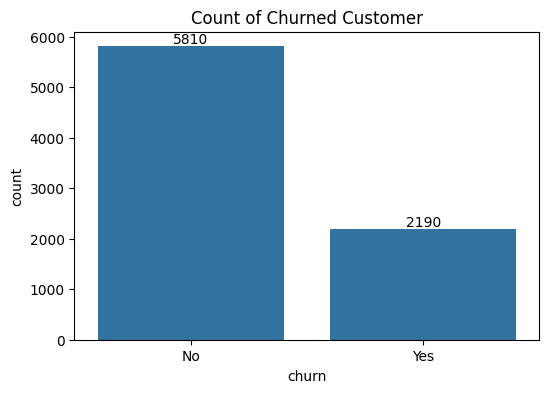

In [49]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x="churn", data=df)
for container in ax.containers:
    ax.bar_label(container)
plt.title("Count of Churned Customer")
plt.show()

In [42]:
# if i want to check the percentage of churn people

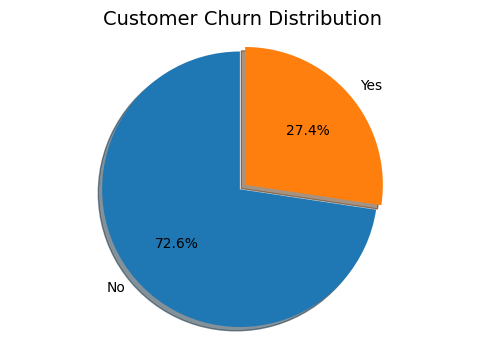

In [45]:
churn_counts = df['churn'].value_counts()
plt.figure(figsize=(6,4))
plt.pie(
    churn_counts,
    labels=churn_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    explode=[0.05, 0], 
    shadow=True
)
plt.title("Customer Churn Distribution", fontsize=14)
plt.axis('equal')
plt.show()

In [50]:
# let us find the reason behind it

In [51]:
# let us explore this by gender column

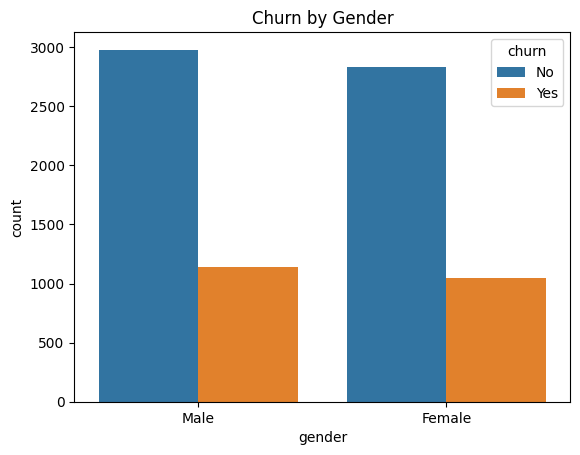

In [58]:
sns.countplot(x='gender',data=df,hue='churn')
plt.title("Churn by Gender")
plt.show()

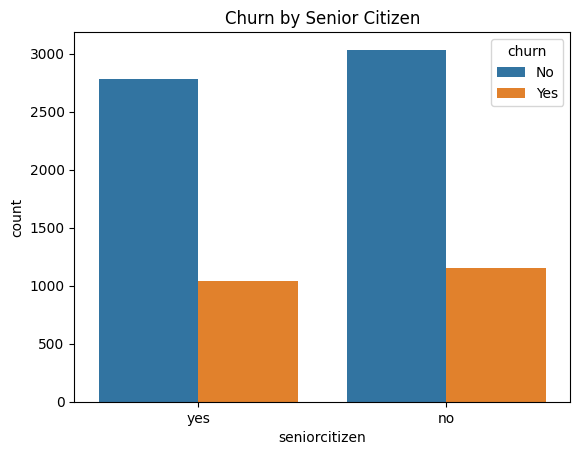

In [60]:
sns.countplot(x='seniorcitizen',data=df,hue='churn')
plt.title("Churn by Senior Citizen")
plt.show()

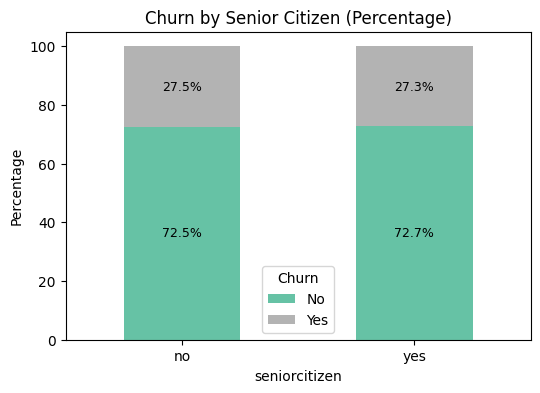

In [62]:
ct = pd.crosstab(df['seniorcitizen'], df['churn'])
ct_percent = ct.div(ct.sum(axis=1), axis=0) * 100
ax = ct_percent.plot(
    kind='bar',
    stacked=True,
    figsize=(6,4),
    colormap='Set2'
)
for i in range(len(ct_percent)):
    cumulative = 0
    for j in range(len(ct_percent.columns)):
        value = ct_percent.iloc[i, j]
        ax.text(
            i,
            cumulative + value / 2,
            f"{value:.1f}%",
            ha='center',
            va='center',
            fontsize=9,
            color='black'
        )
        cumulative += value

plt.title("Churn by Senior Citizen (Percentage)")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

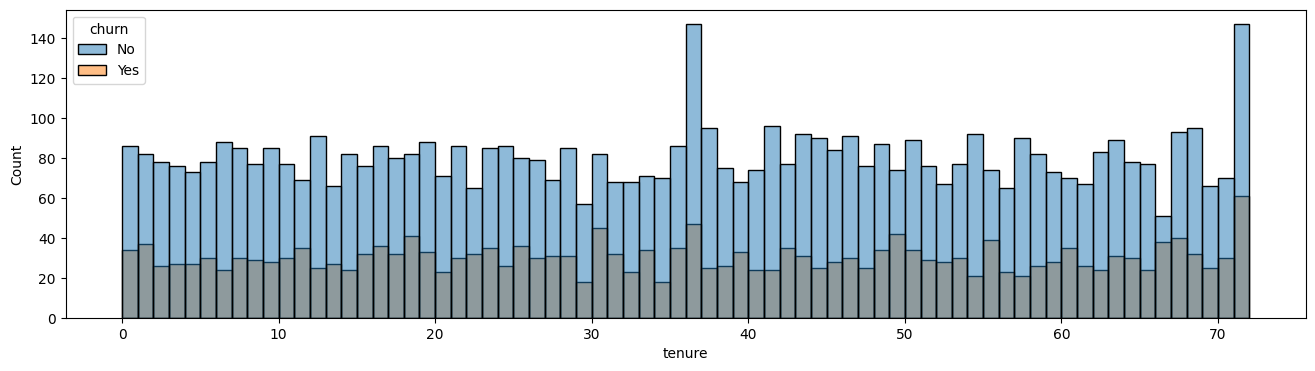

In [85]:
plt.figure(figsize=(16,4))
sns.histplot(x='tenure',data=df,bins=72,hue='churn')
plt.show()

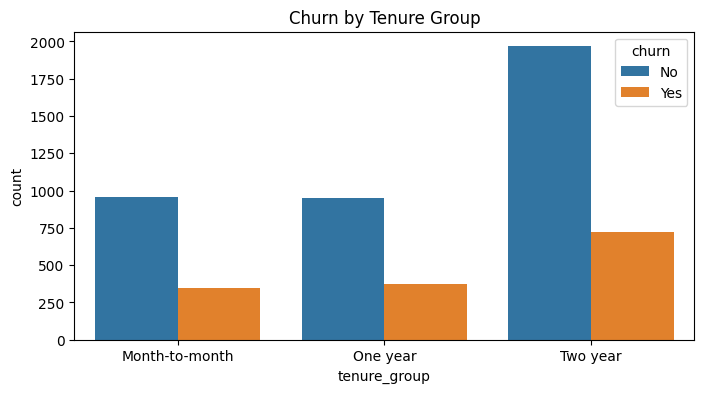

In [84]:
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0,12,24,48],
    labels=['Month-to-month','One year','Two year']
)

plt.figure(figsize=(8,4))

sns.countplot(x='tenure_group', data=df, hue='churn')

plt.title("Churn by Tenure Group")
plt.xticks(rotation=0)
plt.show()

In [ ]:
#people who have Two Years are liklely to churn then free form those who have 1 or month to month and one year to contract

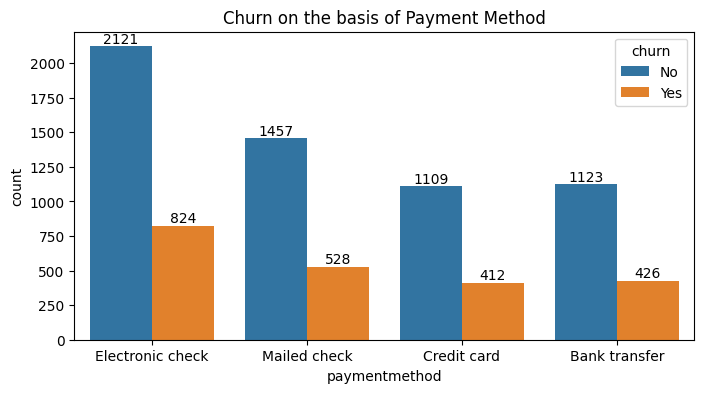

In [104]:
plt.figure(figsize=(8,4))
ax = sns.countplot(x='paymentmethod', data=df, hue='churn')
for container in ax.containers:
    ax.bar_label(container)
plt.title("Churn on the basis of Payment Method")
plt.show()

In [92]:
df.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservices',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn',
       'tenure_group'],
      dtype='object')

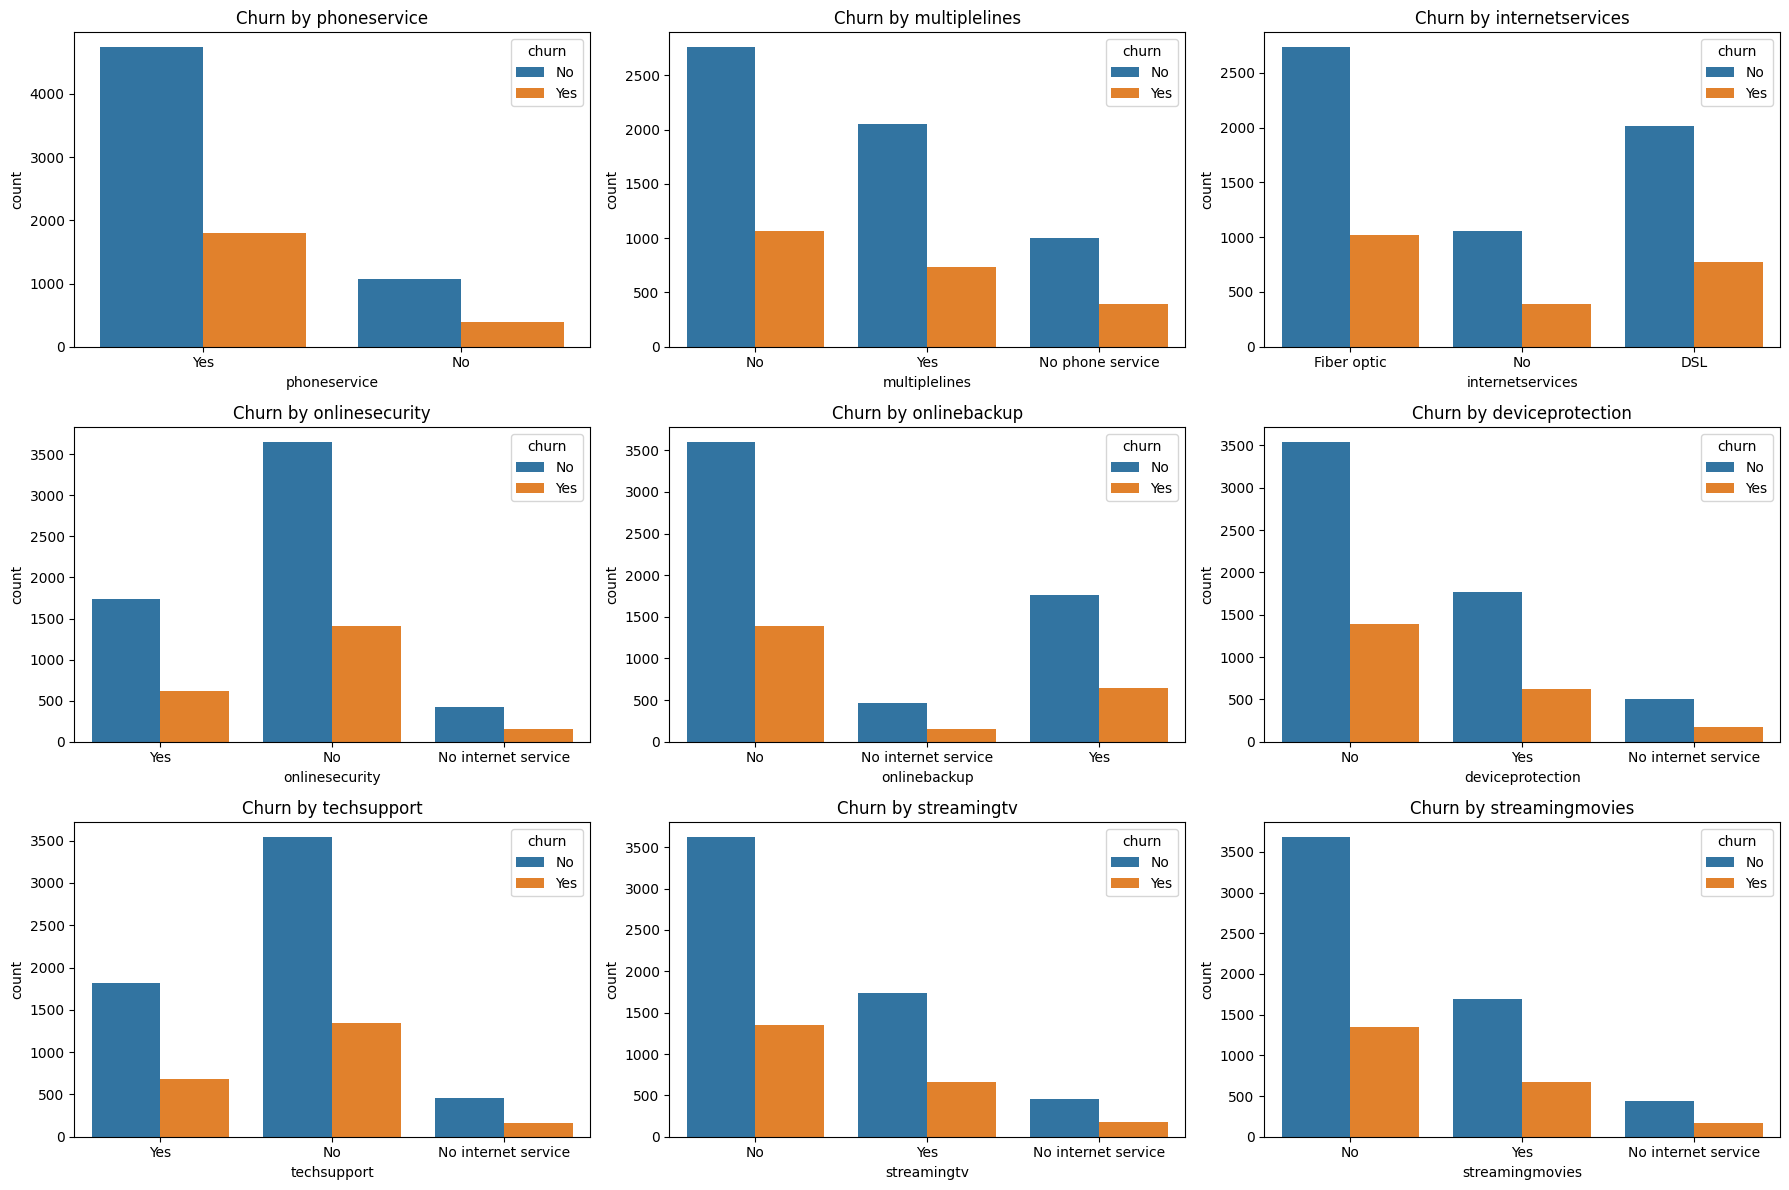

In [106]:
cols = [
    'phoneservice', 'multiplelines', 'internetservices',
    'onlinesecurity', 'onlinebackup', 'deviceprotection',
    'techsupport', 'streamingtv', 'streamingmovies'
]
plt.figure(figsize=(18,12))
for i, col in enumerate(cols, 1):
    plt.subplot(3, 3, i)
    sns.countplot(x=col, data=df, hue='churn')
    plt.title(f'Churn by {col}')
    plt.tight_layout()
plt.show()

In [101]:
#Customers without OnlineSecurity and TechSupport show noticeably higher churn compared to those who have these services.
#Customers not using OnlineBackup and DeviceProtection also tend to churn more.
#InternetServices type shows variation in churn, with some service types contributing more to customer exit.
#PhoneService and MultipleLines have relatively smaller differences in churn behavior.
#StreamingTV and StreamingMovies show moderate churn differences but are not the strongest churn drivers.